In [20]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# S&P 500 tickers via yfinance directly
sp500_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'BRK-B', 'LLY', 'AVGO',
    'JPM', 'TSLA', 'UNH', 'V', 'XOM', 'MA', 'JNJ', 'PG', 'HD', 'COST',
    'MRK', 'ABBV', 'CVX', 'CRM', 'BAC', 'NFLX', 'AMD', 'PEP', 'KO', 'TMO',
    'ACN', 'MCD', 'CSCO', 'ADBE', 'WMT', 'ABT', 'DHR', 'TXN', 'LIN', 'NEE',
    'PM', 'ORCL', 'QCOM', 'IBM', 'RTX', 'GE', 'HON', 'AMGN', 'INTU', 'SPGI',
    'CAT', 'GS', 'MS', 'BLK', 'SYK', 'ELV', 'PFE', 'AXP', 'ISRG', 'BKNG',
    'T', 'VRTX', 'REGN', 'MDT', 'GILD', 'PLD', 'C', 'CB', 'ADI', 'SCHW',
    'BMY', 'MO', 'SO', 'MMC', 'ZTS', 'DUK', 'CI', 'CL', 'TJX', 'CME',
    'EOG', 'SLB', 'WFC', 'USB', 'PNC', 'TGT', 'F', 'GM', 'UBER', 'ABNB'
]

print(f"Total tickers: {len(sp500_tickers)}")
print("Sample:", sp500_tickers[:10])

Total tickers: 90
Sample: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'BRK-B', 'LLY', 'AVGO']


In [22]:
from datetime import datetime, timedelta

# Date ranges
end_date = datetime.today()
start_date_1y = end_date - timedelta(days=365)      # 1 year for multibagger analysis
start_date_1w = end_date - timedelta(days=7)         # 1 week for gainers/losers
start_date_1m = end_date - timedelta(days=30)        # 1 month for monthly performance

# Download 1 year of data for all tickers
print("Downloading data... please wait")
raw_data = yf.download(sp500_tickers, start=start_date_1y, end=end_date, auto_adjust=True)

# Extract closing prices
close_prices = raw_data['Close']
print(f"\nData shape: {close_prices.shape}")
print(f"Date range: {close_prices.index[0].date()} to {close_prices.index[-1].date()}")
print(f"Stocks loaded: {close_prices.shape[1]}")

[**                     4%                       ]  4 of 90 completed

[**********************56%**                     ]  50 of 90 completed$MMC: possibly delisted; no timezone found
[*********************100%***********************]  90 of 90 completed

1 Failed download:
['MMC']: possibly delisted; no timezone found



Data shape: (251, 90)
Date range: 2025-05-19 to 2026-05-18
Stocks loaded: 90


In [23]:
# ============================================
# PART 1 — LAST WEEK TOP GAINERS & LOSERS
# ============================================

# Get last week's data
week_start = close_prices.index[-6]
week_end = close_prices.index[-1]

week_return = ((close_prices.loc[week_end] - close_prices.loc[week_start]) / 
                close_prices.loc[week_start] * 100).dropna()

top_gainers = week_return.nlargest(10)
top_losers = week_return.nsmallest(10)

print("=" * 45)
print("TOP 10 GAINERS — LAST WEEK")
print("=" * 45)
for ticker, ret in top_gainers.items():
    print(f"{ticker:<10} {ret:+.2f}%")

print("\n" + "=" * 45)
print("TOP 10 LOSERS — LAST WEEK")
print("=" * 45)
for ticker, ret in top_losers.items():
    print(f"{ticker:<10} {ret:+.2f}%")

TOP 10 GAINERS — LAST WEEK
CSCO       +20.42%
SYK        +10.84%
F          +9.50%
CME        +7.98%
XOM        +7.95%
COST       +7.70%
MO         +7.45%
EOG        +7.26%
ABT        +6.48%
CVX        +6.16%

TOP 10 LOSERS — LAST WEEK
QCOM       -14.27%
REGN       -11.66%
AMD        -8.24%
TSLA       -7.87%
CAT        -6.78%
NEE        -6.12%
GE         -4.91%
ORCL       -3.73%
HD         -3.72%
GM         -2.91%


In [24]:
# Get full S&P 500 list using requests instead of pandas read_html
import requests
from bs4 import BeautifulSoup

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table', {'id': 'constituents'})

tickers_full = []
for row in table.findAll('tr')[1:]:
    ticker = row.findAll('td')[0].text.strip()
    tickers_full.append(ticker.replace('.', '-'))  # Yahoo Finance uses - not .

print(f"Total tickers retrieved: {len(tickers_full)}")
print("Sample:", tickers_full[:10])


Total tickers retrieved: 503
Sample: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


Full S&P500 Analysis (503 stocks)

In [25]:
print("Downloading data for all 503 stocks")
raw_data_full = yf.download(tickers_full, start=start_date_1y, end=end_date, auto_adjust=True)

close_prices_full = raw_data_full['Close']
print(f"\nData shape: {close_prices_full.shape}")
print(f"Date range: {close_prices_full.index[0].date()} to {close_prices_full.index[-1].date()}")
print(f"Stocks loaded: {close_prices_full.shape[1]}")


[                       1%                       ]  6 of 503 completed

[*********************100%***********************]  503 of 503 completed



Data shape: (251, 503)
Date range: 2025-05-19 to 2026-05-18
Stocks loaded: 503


In [26]:
# ============================================
# FULL S&P 500 — LAST WEEK TOP GAINERS & LOSERS
# ============================================

week_start = close_prices_full.index[-6]
week_end = close_prices_full.index[-1]

week_return = ((close_prices_full.loc[week_end] - close_prices_full.loc[week_start]) / 
                close_prices_full.loc[week_start] * 100).dropna()

top_gainers = week_return.nlargest(10)
top_losers = week_return.nsmallest(10)

print("=" * 45)
print("TOP 10 GAINERS — LAST WEEK (S&P 500)")
print("=" * 45)
for ticker, ret in top_gainers.items():
    print(f"{ticker:<10} {ret:+.2f}%")

print("\n" + "=" * 45)
print("TOP 10 LOSERS — LAST WEEK (S&P 500)")
print("=" * 45)
for ticker, ret in top_losers.items():
    print(f"{ticker:<10} {ret:+.2f}%")

# ============================================
# FULL S&P 500 — MULTIBAGGER SCREENING
# ============================================

results_full = []

for ticker in close_prices_full.columns:
    prices = close_prices_full[ticker].dropna()
    if len(prices) < 200:
        continue
    
    ret_1y = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
    ret_1m = (prices.iloc[-1] / prices.iloc[-22] - 1) * 100
    rolling_max = prices.cummax()
    drawdown = ((prices - rolling_max) / rolling_max).min() * 100
    daily_ret = prices.pct_change().dropna()
    volatility = daily_ret.std() * np.sqrt(252) * 100

    results_full.append({
        'Ticker': ticker,
        '1Y Return (%)': round(ret_1y, 2),
        '1M Return (%)': round(ret_1m, 2),
        'Max Drawdown (%)': round(drawdown, 2),
        'Volatility (%)': round(volatility, 2)
    })

results_df_full = pd.DataFrame(results_full)

multibaggers_full = results_df_full[
    (results_df_full['1Y Return (%)'] > 30) &
    (results_df_full['1M Return (%)'] > 5) &
    (results_df_full['Max Drawdown (%)'] > -40)
].sort_values('1Y Return (%)', ascending=False)

print("\n" + "=" * 65)
print("POTENTIAL MULTIBAGGER STOCKS — FULL S&P 500")
print("=" * 65)
print(multibaggers_full.to_string(index=False))
print(f"\nTotal candidates found: {len(multibaggers_full)}")

TOP 10 GAINERS — LAST WEEK (S&P 500)
CSCO       +20.42%
ZBRA       +19.87%
PANW       +15.86%
CRWD       +14.12%
NOW        +13.04%
HUM        +11.57%
SYK        +10.84%
DXCM       +9.71%
FTNT       +9.58%
F          +9.50%

TOP 10 LOSERS — LAST WEEK (S&P 500)
INTC       -16.43%
ALB        -16.31%
LITE       -15.96%
MU         -14.31%
QCOM       -14.27%
GLW        -13.91%
SNDK       -13.86%
CVNA       -13.39%
COIN       -12.54%
CEG        -12.44%

POTENTIAL MULTIBAGGER STOCKS — FULL S&P 500
Ticker  1Y Return (%)  1M Return (%)  Max Drawdown (%)  Volatility (%)
  SNDK        3337.36          44.74            -31.34           97.59
   WDC         808.24          23.13            -20.59           62.90
    MU         592.52          49.77            -30.28           63.28
   STX         588.18          35.25            -21.00           62.69
  INTC         405.94          57.91            -24.17           71.55
  COHR         357.08           5.16            -26.52           69.76
   FIX 

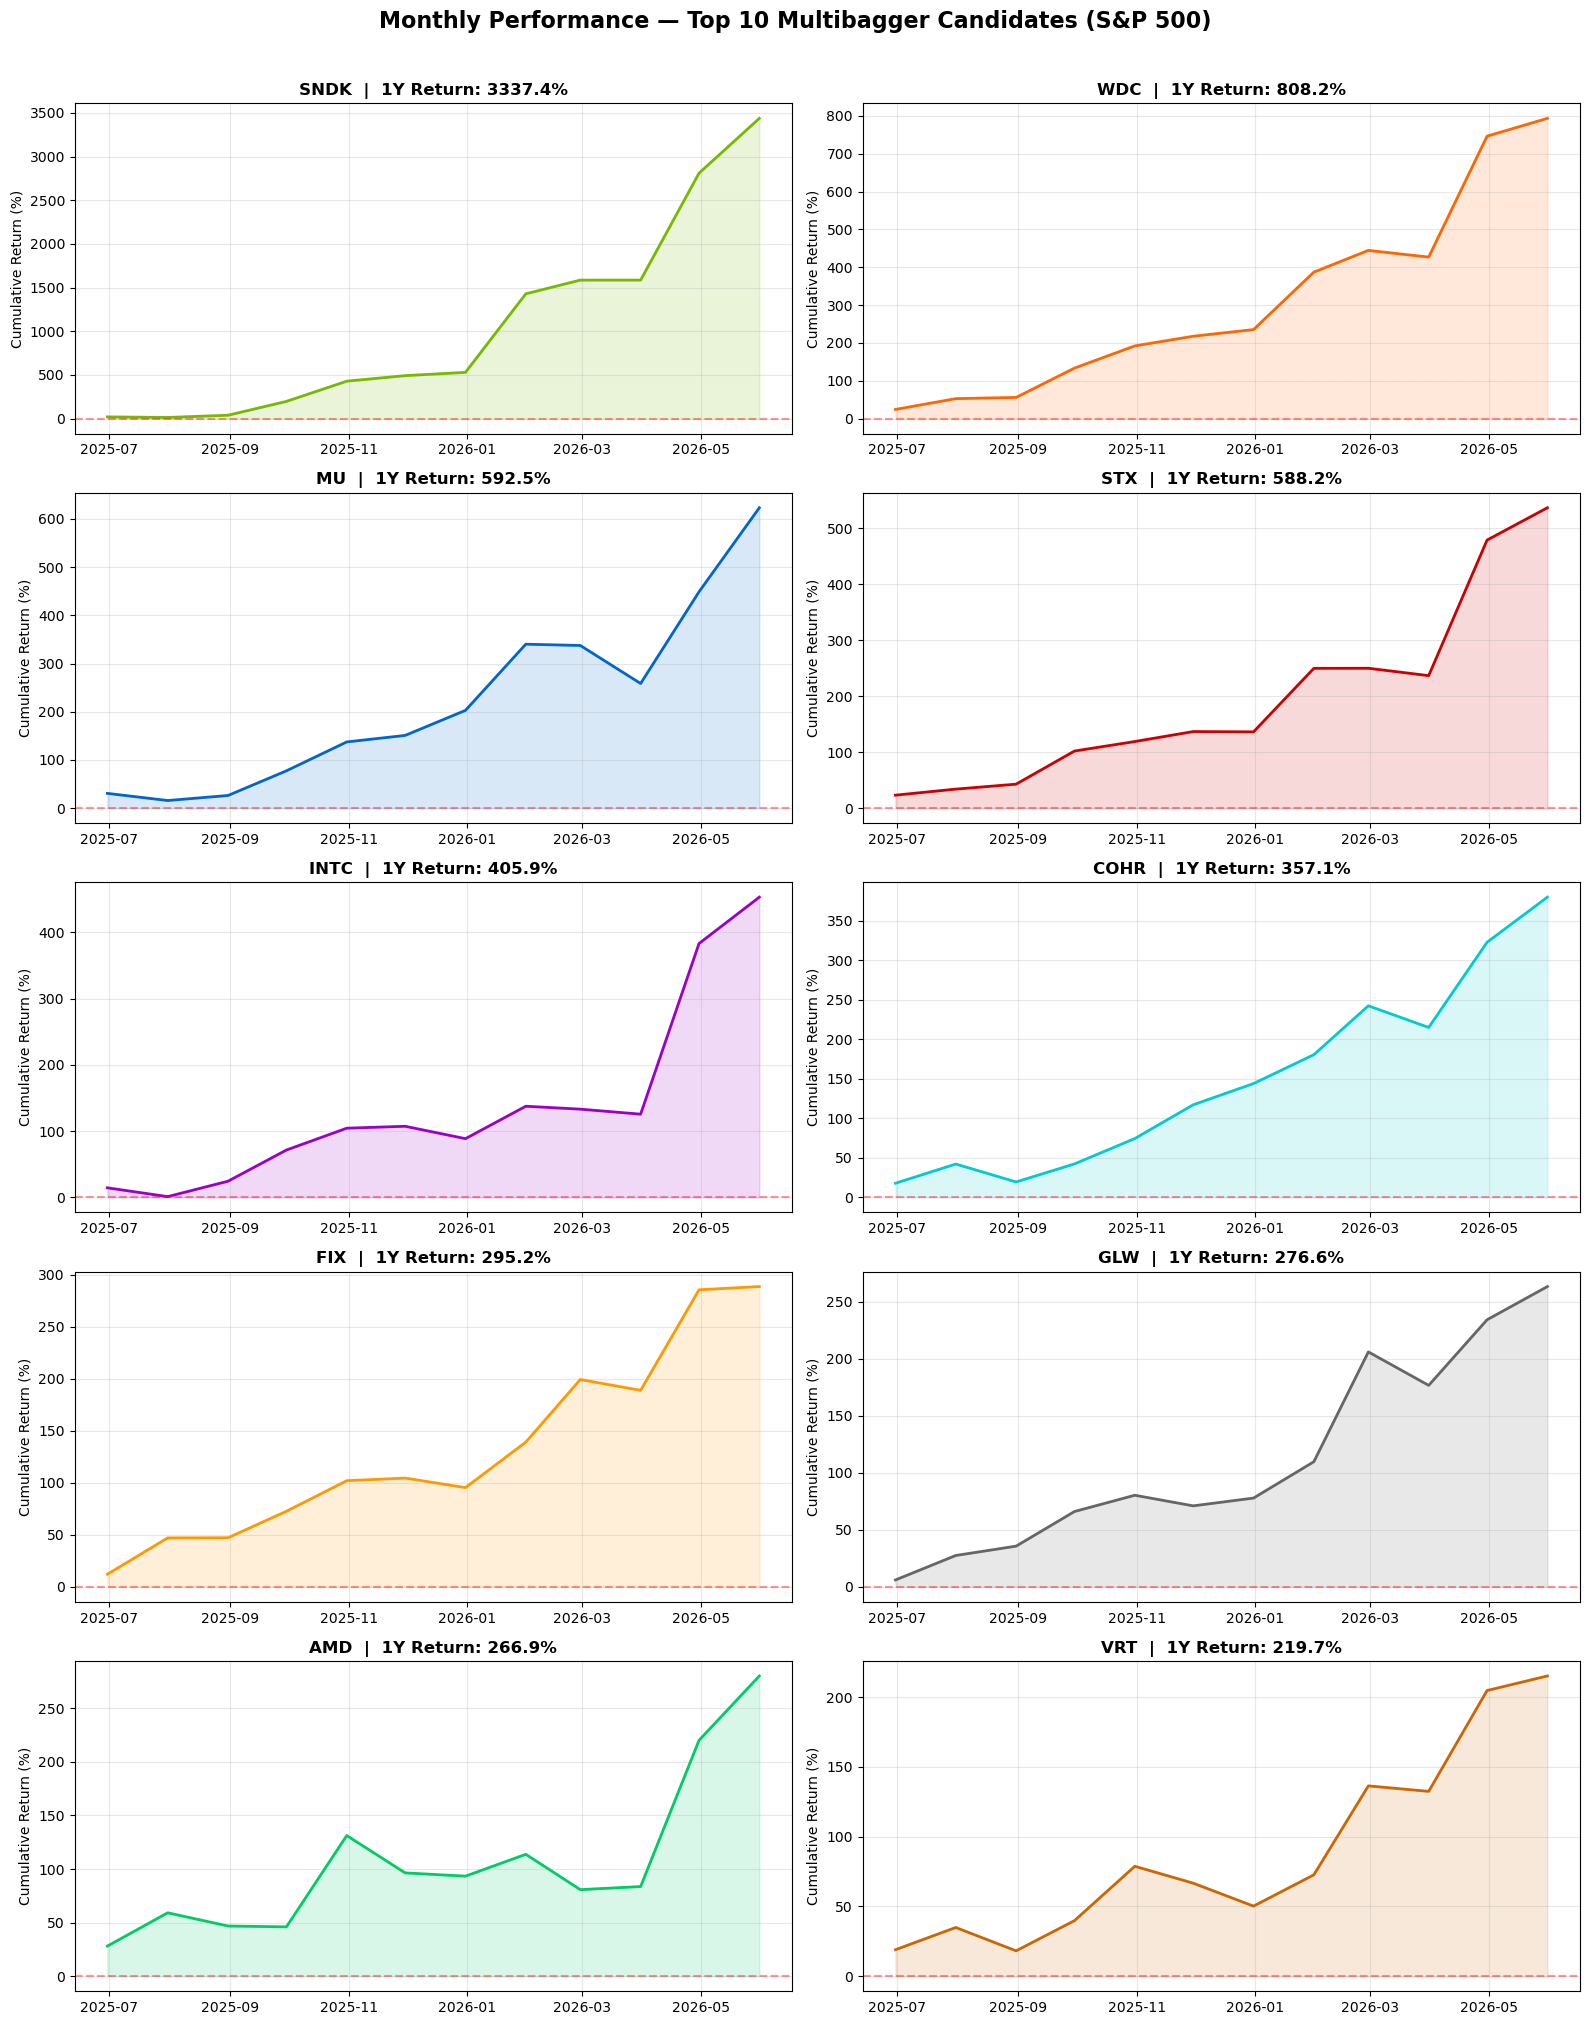

In [27]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

colors = ['#76b900', '#ff6600', '#0066cc', '#cc0000', '#9900cc', 
          '#00cccc', '#ff9900', '#666666', '#00cc66', '#cc6600']

for i, ticker in enumerate(top10):
    monthly = monthly_returns[ticker].dropna()
    cumulative = (1 + monthly / 100).cumprod() - 1
    
    axes[i].plot(cumulative.index, cumulative * 100, 
                 color=colors[i], linewidth=2)
    axes[i].fill_between(cumulative.index, cumulative * 100, 
                         alpha=0.15, color=colors[i])
    axes[i].set_title(f'{ticker}  |  1Y Return: {multibaggers_full[multibaggers_full["Ticker"]==ticker]["1Y Return (%)"].values[0]:.1f}%', 
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cumulative Return (%)')
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.4)

plt.suptitle('Monthly Performance — Top 10 Multibagger Candidates (S&P 500)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# ============================================
# FINAL SUMMARY
# ============================================

print("=" * 65)
print("S&P 500 STOCK ANALYSIS SUMMARY")
print("=" * 65)

print(f"\n📈 TOP 5 GAINERS LAST WEEK:")
for ticker, ret in top_gainers.head(5).items():
    print(f"   {ticker:<10} {ret:+.2f}%")

print(f"\n📉 TOP 5 LOSERS LAST WEEK:")
for ticker, ret in top_losers.head(5).items():
    print(f"   {ticker:<10} {ret:+.2f}%")

print(f"\n🚀 TOP 10 MULTIBAGGER CANDIDATES:")
for _, row in multibaggers_full.head(10).iterrows():
    print(f"   {row['Ticker']:<10} 1Y: {row['1Y Return (%)']:>8.1f}%   1M: {row['1M Return (%)']:>6.1f}%   Drawdown: {row['Max Drawdown (%)']:>7.1f}%")

print(f"\n📊 Total multibagger candidates found: {len(multibaggers_full)}")
print(f"📊 Total stocks screened: 503")
print("=" * 65)

S&P 500 STOCK ANALYSIS SUMMARY

📈 TOP 5 GAINERS LAST WEEK:
   CSCO       +20.42%
   ZBRA       +19.87%
   PANW       +15.86%
   CRWD       +14.12%
   NOW        +13.04%

📉 TOP 5 LOSERS LAST WEEK:
   INTC       -16.43%
   ALB        -16.31%
   LITE       -15.96%
   MU         -14.31%
   QCOM       -14.27%

🚀 TOP 10 MULTIBAGGER CANDIDATES:
   SNDK       1Y:   3337.4%   1M:   44.7%   Drawdown:   -31.3%
   WDC        1Y:    808.2%   1M:   23.1%   Drawdown:   -20.6%
   MU         1Y:    592.5%   1M:   49.8%   Drawdown:   -30.3%
   STX        1Y:    588.2%   1M:   35.2%   Drawdown:   -21.0%
   INTC       1Y:    405.9%   1M:   57.9%   Drawdown:   -24.2%
   COHR       1Y:    357.1%   1M:    5.2%   Drawdown:   -26.5%
   FIX        1Y:    295.2%   1M:   12.4%   Drawdown:   -13.8%
   GLW        1Y:    276.6%   1M:    8.6%   Drawdown:   -23.0%
   AMD        1Y:    266.9%   1M:   51.2%   Drawdown:   -27.8%
   VRT        1Y:    219.7%   1M:   10.5%   Drawdown:   -24.8%

📊 Total multibagger candidate

In [29]:
# ============================================
# EXPORT ALL RESULTS TO CSV
# ============================================

save_path = r'C:\Users\Travis Cheong\Downloads\\'

# 1. Multibagger candidates
multibaggers_full.to_csv(save_path + 'multibagger_candidates.csv', index=False)

# 2. Top gainers & losers
gainers_df = top_gainers.reset_index()
gainers_df.columns = ['Ticker', 'Weekly Return (%)']
gainers_df.to_csv(save_path + 'top_gainers.csv', index=False)

losers_df = top_losers.reset_index()
losers_df.columns = ['Ticker', 'Weekly Return (%)']
losers_df.to_csv(save_path + 'top_losers.csv', index=False)

# 3. Monthly returns of top 10 multibaggers
monthly_returns[top10].to_csv(save_path + 'monthly_performance.csv')

print("✅ Done")


✅ Done
